In [21]:
import joblib
import pandas as pd

In [22]:
# Load saved model aur features
model = joblib.load('../Model/xgboost_electricity_model.pkl')
feature_columns = joblib.load('../Model/feature_columns.pkl')

print("✅ Model loaded!")
print(f"Features: {feature_columns}")

✅ Model loaded!
Features: ['lag_1', 'lag_24', 'lag_168', 'rolling_24_mean', 'rolling_168_mean', 'hour', 'day_of_week', 'weekend', 'holiday', 'temperature']


In [23]:
df = pd.read_csv('../Data/feature-columns.csv') 
df['datetime'] = pd.to_datetime(df['datetime'])  
df.set_index('datetime', inplace=True)

print(df.tail())
print(f"\nLast timestamp: {df.index[-1]}")
print(f"Target column: {df.columns.tolist()}")  

                      lag_1  lag_24  lag_168  rolling_24_mean  \
datetime                                                        
2023-12-31 19:00:00  5602.1  5822.5   5479.5      4808.679167   
2023-12-31 20:00:00  5583.6  5662.5   5664.7      4798.725000   
2023-12-31 21:00:00  5564.2  5579.5   5665.8      4794.629167   
2023-12-31 22:00:00  5792.4  4610.6   4854.6      4803.500000   
2023-12-31 23:00:00  4533.6  4658.1   4403.3      4800.291667   

                     rolling_168_mean  hour  day_of_week  weekend  holiday  \
datetime                                                                     
2023-12-31 19:00:00       4999.605952    19            6        1        1   
2023-12-31 20:00:00       5000.225595    20            6        1        1   
2023-12-31 21:00:00       4999.627381    21            6        1        1   
2023-12-31 22:00:00       5000.380952    22            6        1        1   
2023-12-31 23:00:00       4998.470238    23            6        1        1  

In [24]:
target_col = 'demand_MW'
history = df[target_col].iloc[-200:].copy()

In [25]:
last_temp = df['temperature'].iloc[-1]
avg_temp_by_hour = df.groupby(df.index.hour)['temperature'].mean()

In [26]:
def is_holiday(date):
    return 1

In [27]:
last_timestamp = df.index[-1]
future_timestamps = pd.date_range(
    start=last_timestamp + pd.Timedelta(hours=1),
    periods=24,  
    freq='h'
)

In [28]:
print(f"Forecasting: {future_timestamps[0]} to {future_timestamps[-1]}")

Forecasting: 2024-01-01 00:00:00 to 2024-01-01 23:00:00


In [29]:
predictions = []

for future_time in future_timestamps:
    
    features = {}
    features['lag_1']   = history.iloc[-1]
    features['lag_24']  = history.iloc[-24]  if len(history) >= 24  else history.iloc[0]
    features['lag_168'] = history.iloc[-168] if len(history) >= 168 else history.iloc[0]
    
    features['rolling_24_mean']  = history.iloc[-24:].mean()
    features['rolling_168_mean'] = history.iloc[-168:].mean() if len(history) >= 168 else history.mean()
    
    features['hour'] = future_time.hour
    features['day_of_week'] = future_time.dayofweek
    features['weekend'] = int(future_time.dayofweek >= 5)
    features['holiday'] = is_holiday(future_time)
    features['temperature'] = avg_temp_by_hour.get(future_time.hour, last_temp)
    
    X_future = pd.DataFrame([features])[feature_columns]
    
    pred = model.predict(X_future)[0]
    
    history = pd.concat([history, pd.Series([pred], index=[future_time])])
    
    predictions.append({'datetime': future_time, 'predicted_demand_MW': pred})

forecast_df = pd.DataFrame(predictions)
forecast_df.set_index('datetime', inplace=True)

print("Forecast complete!")
print(forecast_df)

Forecast complete!
                     predicted_demand_MW
datetime                                
2024-01-01 00:00:00          3436.741211
2024-01-01 01:00:00          3531.117920
2024-01-01 02:00:00          3468.901123
2024-01-01 03:00:00          3380.926270
2024-01-01 04:00:00          3617.044678
2024-01-01 05:00:00          4337.496582
2024-01-01 06:00:00          4207.137207
2024-01-01 07:00:00          4412.465332
2024-01-01 08:00:00          4951.079590
2024-01-01 09:00:00          4949.062988
2024-01-01 10:00:00          4939.486328
2024-01-01 11:00:00          4907.904297
2024-01-01 12:00:00          4806.430664
2024-01-01 13:00:00          4650.712402
2024-01-01 14:00:00          4769.864258
2024-01-01 15:00:00          4758.109375
2024-01-01 16:00:00          4847.435059
2024-01-01 17:00:00          4917.520508
2024-01-01 18:00:00          5071.371094
2024-01-01 19:00:00          5160.125000
2024-01-01 20:00:00          5028.586426
2024-01-01 21:00:00          5154.9907

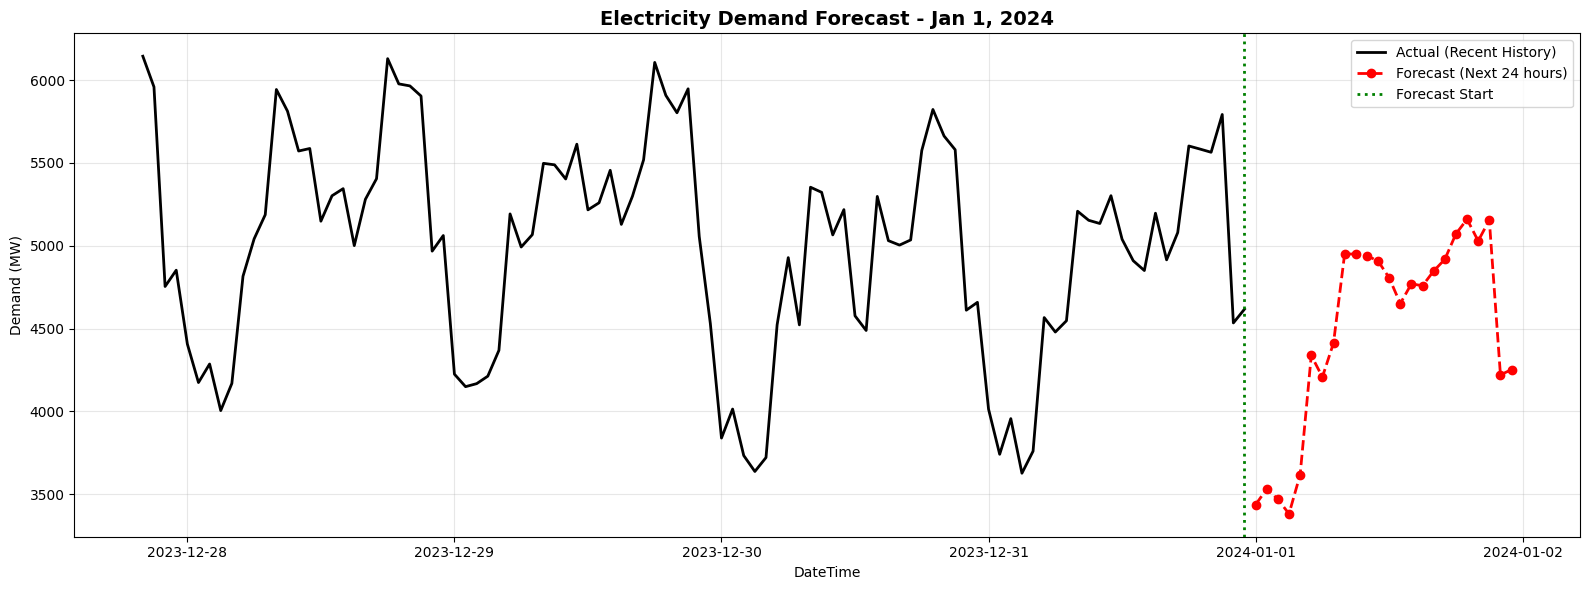

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 6))

plt.plot(df.index[-100:], df[target_col].iloc[-100:], 
         label='Actual (Recent History)', color='black', linewidth=2)

plt.plot(forecast_df.index, forecast_df['predicted_demand_MW'], 
         label='Forecast (Next 24 hours)', color='red', linewidth=2, linestyle='--', marker='o')

plt.axvline(x=last_timestamp, color='green', linestyle=':', linewidth=2, label='Forecast Start')
plt.title('Electricity Demand Forecast - Jan 1, 2024', fontsize=14, fontweight='bold')
plt.xlabel('DateTime')
plt.ylabel('Demand (MW)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()